In [24]:
!git clone https://github.com/beckhamtoh/CS3244-Gun-Violence.git
%cd CS3244-Gun-Violence

Cloning into 'CS3244-Gun-Violence'...
remote: Enumerating objects: 24700, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 24700 (delta 108), reused 97 (delta 39), pack-reused 24508 (from 1)
Receiving objects: 100% (24700/24700), 201.42 MiB | 26.99 MiB/s, done.
Resolving deltas: 100% (2842/2842), done.
/kaggle/working/CS3244-Gun-Violence/CS3244-Gun-Violence/CS3244-Gun-Violence/CS3244-Gun-Violence


In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("../data/cleaned/guns_incident_data_cleaned.csv")
print(df.head())

df = df.drop(columns=["S.No."], errors="ignore")

y = df["Police involvement"] # This is the target variable
X = df.drop(columns=["Police involvement"]) # The features

numeric_cols = ["Year", "Month", "Age"]

# SPLIT FIRST (important! - to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features before one-hot encoding -> helps LR performs better
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# One-hot encode categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

   S.No.  Year  Month        Date   Reason     Education     Sex   Age  \
0      1  2017      1  2017-01-06  Suicide     Bachelors    Male  35.0   
1      2  2017      1  2017-01-19  Suicide  Some college  Female  22.0   
2      3  2017      1  2017-01-01  Suicide     Bachelors    Male  61.0   
3      4  2017      2  2017-02-06  Suicide     Bachelors    Male  65.0   
4      5  2017      2  2017-02-09  Suicide   High School    Male  32.0   

                     Race  Hispanic Place of incident  Police involvement  \
0  Asian/Pacific Islander       100              Home                   0   
1                   White       100            Street                   0   
2                   White       100   Other specified                   0   
3                   White       100              Home                   0   
4                   White       100   Other specified                   0   

  day_of_week  isWeekend  
0      Friday          0  
1    Thursday          0  
2      Sund

## Train Models

In [27]:
# Models experimented: Logistic Regression, Random Forest, XGBoost
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        eval_metric="logloss",
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    )
}

In [28]:
# Metrics used: Accuracy, F1 Score, ROC-AUC
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, prob)
    }

results_df = pd.DataFrame(results).T
print("\n===== MODEL PERFORMANCE =====\n")
print(results_df)


===== MODEL PERFORMANCE =====

                     Accuracy  F1 Score   ROC-AUC
Logistic Regression  0.998810  0.958333  0.999311
Random Forest        0.999802  0.992806  0.991975
XGBoost              0.999504  0.982206  0.998766


Insights:

Best Overall for Classification (F1 Score): → Random Forest
- Highest F1 score → best balance of precision and recall
- Highest accuracy
- Very strong performance across all metrics
If objective: predict police involvement as accurately as possible → choose Random Forest.

Best for Ranking or Probability Quality → Logistic Regression (Best ROC-AUC)
- Highest ROC-AUC (0.999311)
- Means it is best at probability calibration (e.g., ranking which incidents are most likely to involve police)
If objective: understand risk factors or produce interpretable probabilities → choose Logistic Regression.

Most Stable, Best For Large Data → XGBoost
- Very high accuracy + AUC
- Excellent generalisation
- But slightly worse F1 than Random Forest
Use XGBoost when scaling to bigger datasets or when want more robust predictions.

## Evaluation

In [29]:
best_model = models["Random Forest"]

# Smaller sample of the test set to speed up computation
sample_size = 1000 
if len(X_test) > sample_size:
    X_test_sample = X_test.sample(sample_size, random_state=42)
    y_test_sample = y_test.loc[X_test_sample.index]
else:
    X_test_sample = X_test
    y_test_sample = y_test

# Compute permutation importance with parallelization
perm = permutation_importance(
    best_model,
    X_test_sample,
    y_test_sample,
    n_repeats=3,       
    random_state=42,
    n_jobs=-1          
)

# Sort features by importance
sorted_idx = perm.importances_mean.argsort()[::-1]

# Get top 3 features and their scores
top_n = min(3, X_test.shape[1])
top_features = X_test.columns[sorted_idx][:top_n]
top_scores = perm.importances_mean[sorted_idx][:top_n]

# Display results
for feature, score in zip(top_features, top_scores):
    print(f"{feature}: {score:.4f}")

Place of incident_Unspecified: 0.0133
Reason_Homicide: 0.0007
Place of incident_Street: 0.0003


Note:

Permutation importance works by shuffling each feature in the test set and measuring how much the model’s performance drops.

Using a smaller test set (in our case, 1000) means:
- The performance estimates are noisier because fewer examples contribute to the metric.
- Small changes in predictions can inflate or deflate importance values slightly.

However, since our original dataset is large (~100,000), and we sample 1000 rows:
- The ranking of the top features usually stays fairly stable.
- Absolute importance values may vary a bit, but the relative ordering of features is generally reliable.

## Visualisation

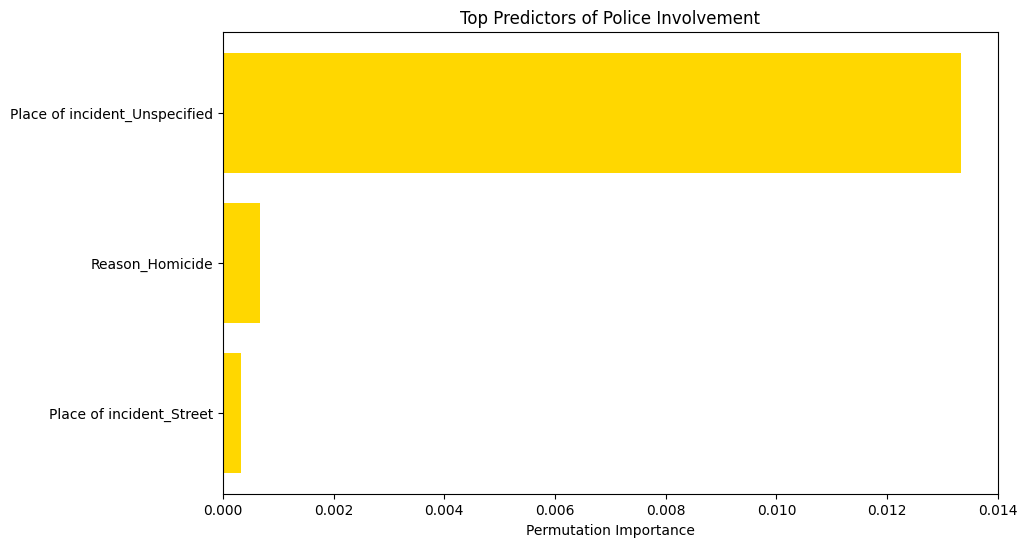

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(top_features, top_scores, color="gold")
plt.gca().invert_yaxis()
plt.title("Top Predictors of Police Involvement")
plt.xlabel("Permutation Importance")
plt.show()

## Error analysis by Location Group

In [31]:
df_test = X_test.copy()
df_test["true"] = y_test
df_test["pred"] = best_model.predict(X_test)

# One-hot "Place of incident" columns
place_cols = df_test.filter(like="Place of incident_").columns

# Assign the most likely location category for each row
df_test["location_group"] = df_test[place_cols].idxmax(axis=1)

# Compute false negative rate per location
error_table = df_test.groupby("location_group").apply(
    lambda g: pd.Series({
        "n": len(g),
        "false_negatives": ((g["true"] == 1) & (g["pred"] == 0)).sum(),
        "fn_rate": ((g["true"] == 1) & (g["pred"] == 0)).sum() / max(1, (g["true"] == 1).sum())
    })
)

print("\n===== FALSE NEGATIVE RATE BY LOCATION =====\n")
print(error_table)


===== FALSE NEGATIVE RATE BY LOCATION =====

                                                 n  false_negatives  fn_rate
location_group                                                              
Place of incident_Home                     12143.0              1.0      1.0
Place of incident_Industrial/construction     58.0              0.0      0.0
Place of incident_Other specified           2790.0              0.0      0.0
Place of incident_Other unspecified         1752.0              2.0      1.0
Place of incident_Residential institution     38.0              0.0      0.0
Place of incident_School/instiution          133.0              0.0      0.0
Place of incident_Sports                      29.0              0.0      0.0
Place of incident_Street                    2256.0              1.0      1.0
Place of incident_Trade/service area         685.0              0.0      0.0
Place of incident_Unspecified                276.0              0.0      0.0


/tmp/ipykernel_47/4128407555.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_table = df_test.groupby("location_group").apply(


## Summary: Classification Report

In [32]:
print("\n===== CLASSIFICATION REPORT (BEST MODEL) =====\n")
print(classification_report(y_test, best_model.predict(X_test)))


===== CLASSIFICATION REPORT (BEST MODEL) =====

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19880
           1       1.00      0.99      0.99       280

    accuracy                           1.00     20160
   macro avg       1.00      0.99      1.00     20160
weighted avg       1.00      1.00      1.00     20160

